In [1]:
!pip install -q gdown

In [2]:
import os
import re
import string
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)

from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully.")

TensorFlow version: 2.20.0
All libraries imported successfully.


In [3]:
import gdown

file_id = "1HEcyWf93HxbJeC5kE0nLQH8fPevEiUhM"

download_url = f"https://drive.google.com/uc?id={file_id}"

dataset_path = "/content/twitter_sentiment.csv"

gdown.download(
    download_url,
    dataset_path,
    quiet=False
)

print("Dataset downloaded successfully.")
print("Dataset path:", dataset_path)

Downloading...
From: https://drive.google.com/uc?id=1HEcyWf93HxbJeC5kE0nLQH8fPevEiUhM
To: /content/twitter_sentiment.csv
100%|██████████| 1.26M/1.26M [00:00<00:00, 95.6MB/s]

Dataset downloaded successfully.
Dataset path: /content/twitter_sentiment.csv


In [4]:
df = pd.read_csv(
    dataset_path,
    encoding="latin1"
)

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset Shape:
(9093, 3)

First 5 rows:


,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [5]:
print("COLUMN NAMES")
print("=" * 70)

for i, column in enumerate(df.columns):
    print(i, ":", repr(column))

COLUMN NAMES
0 : 'tweet_text'
1 : 'emotion_in_tweet_is_directed_at'
2 : 'is_there_an_emotion_directed_at_a_brand_or_product'


In [6]:
display(df.head(10))

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion
5,@teachntech00 New iPad Apps For #SpeechTherapy...,NaN,No emotion toward brand or product
6,NaN,NaN,No emotion toward brand or product
7,"#SXSW is just starting, #CTIA is around the co...",Android,Positive emotion
8,Beautifully smart and simple idea RT @madebyma...,iPad or iPhone App,Positive emotion
9,Counting down the days to #sxsw plus strong Ca...,Apple,Positive emotion


In [7]:
print(df.columns.tolist())

['tweet_text', 'emotion_in_tweet_is_directed_at', 'is_there_an_emotion_directed_at_a_brand_or_product']


In [8]:
tweet_column = None
sentiment_column = None

for column in df.columns:

    col_lower = str(column).lower()

    if "tweet" in col_lower and "directed" not in col_lower:
        tweet_column = column

    if (
        "emotion" in col_lower
        and "directed" in col_lower
        and "brand" in col_lower
    ):
        sentiment_column = column


print("Tweet column:")
print(tweet_column)

print("\nSentiment column:")
print(sentiment_column)

Tweet column:
tweet_text

Sentiment column:
is_there_an_emotion_directed_at_a_brand_or_product


In [9]:
data = df[
    [
        tweet_column,
        sentiment_column
    ]
].copy()

data.columns = [
    "tweet",
    "sentiment"
]

print("Working Dataset:")

display(data.head())

Working Dataset:


,tweet,sentiment
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Positive emotion


In [10]:
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
tweet        1
sentiment    0
dtype: int64


In [11]:
data = data.dropna(
    subset=[
        "tweet",
        "sentiment"
    ]
)

data = data.reset_index(drop=True)

print("Dataset Shape After Removing Missing Values:")
print(data.shape)

Dataset Shape After Removing Missing Values:
(9092, 2)


In [12]:
print("Original Sentiment Classes:")
print(data["sentiment"].value_counts())

Original Sentiment Classes:
sentiment
No emotion toward brand or product    5388
Positive emotion                      2978
Negative emotion                       570
I can't tell                           156
Name: count, dtype: int64


In [13]:
print("\nUnique Sentiment Labels:")

for sentiment in data["sentiment"].unique():
    print(repr(sentiment))


Unique Sentiment Labels:
'Negative emotion'
'Positive emotion'
'No emotion toward brand or product'
"I can't tell"


In [14]:
def standardize_sentiment(value):

    value = str(value).lower().strip()

    if "positive" in value:
        return "Positive"

    elif "negative" in value:
        return "Negative"

    elif "no emotion" in value:
        return "Neutral"

    elif (
        "can't tell" in value
        or "cannot tell" in value
        or "no idea" in value
    ):
        return "No_idea"

    else:
        return "No_idea"

In [15]:
data["sentiment"] = data["sentiment"].apply(
    standardize_sentiment
)

print("Standardized Sentiment Classes:")

print(
    data["sentiment"].value_counts()
)

Standardized Sentiment Classes:
sentiment
Neutral     5388
Positive    2978
Negative     570
No_idea      156
Name: count, dtype: int64


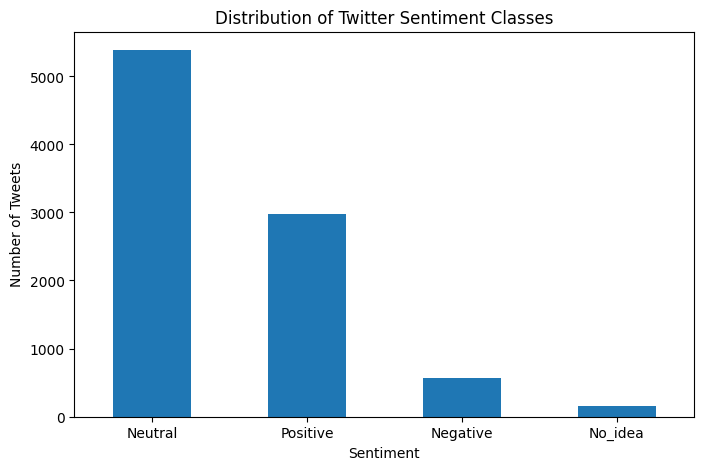

In [16]:
sentiment_counts = data[
    "sentiment"
].value_counts()

plt.figure(figsize=(8, 5))

sentiment_counts.plot(
    kind="bar"
)

plt.title(
    "Distribution of Twitter Sentiment Classes"
)

plt.xlabel("Sentiment")

plt.ylabel("Number of Tweets")

plt.xticks(rotation=0)

plt.show()

In [17]:
def clean_tweet(text):

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    # Remove @mentions
    text = re.sub(
        r"@\w+",
        " ",
        text
    )

    # Keep hashtag word but remove #
    text = re.sub(
        r"#",
        "",
        text
    )

    # Remove HTML entities
    text = re.sub(
        r"&\w+;",
        " ",
        text
    )

    # Remove numbers
    text = re.sub(
        r"\d+",
        " ",
        text
    )

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

In [18]:
data["clean_tweet"] = data[
    "tweet"
].apply(clean_tweet)

display(
    data[
        [
            "tweet",
            "clean_tweet",
            "sentiment"
        ]
    ].head(10)
)

,tweet,clean_tweet,sentiment
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,i have a g iphone after hrs tweeting at riseau...,Negative
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know about awesome ipadiphone app that youll l...,Positive
2,@swonderlin Can not wait for #iPad 2 also. The...,can not wait for ipad also they should sale th...,Positive
3,@sxsw I hope this year's festival isn't as cra...,i hope this years festival isnt as crashy as t...,Negative
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff on fri sxsw marissa mayer google t...,Positive
5,@teachntech00 New iPad Apps For #SpeechTherapy...,new ipad apps for speechtherapy and communicat...,Neutral
6,"#SXSW is just starting, #CTIA is around the co...",sxsw is just starting ctia is around the corne...,Positive
7,Beautifully smart and simple idea RT @madebyma...,beautifully smart and simple idea rt wrote abo...,Positive
8,Counting down the days to #sxsw plus strong Ca...,counting down the days to sxsw plus strong can...,Positive
9,Excited to meet the @samsungmobileus at #sxsw ...,excited to meet the at sxsw so i can show them...,Positive


In [19]:
data = data[
    data["clean_tweet"].str.len() > 0
].copy()

data = data.reset_index(drop=True)

print("Final Dataset Shape:")
print(data.shape)

Final Dataset Shape:
(9092, 3)


In [20]:
label_encoder = LabelEncoder()

data["label"] = label_encoder.fit_transform(
    data["sentiment"]
)

print("Label Mapping:")

for index, class_name in enumerate(
    label_encoder.classes_
):

    print(
        class_name,
        "=",
        index
    )

Label Mapping:
Negative = 0
Neutral = 1
No_idea = 2
Positive = 3


In [21]:
X = data[
    "clean_tweet"
].values

y = data[
    "label"
].values

print("Number of Tweets:", len(X))
print("Number of Labels:", len(y))

Number of Tweets: 9092
Number of Labels: 9092


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 7273
Testing Samples: 1819


In [23]:
VOCAB_SIZE = 10000

In [24]:
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    X_train
)

In [25]:
print(
    "Total words found:",
    len(tokenizer.word_index)
)

Total words found: 9002


In [27]:
X_train_sequences = tokenizer.texts_to_sequences(
    X_train
)

X_test_sequences = tokenizer.texts_to_sequences(
    X_test
)

In [28]:
sequence_lengths = [
    len(sequence)
    for sequence in X_train_sequences
]

print(
    "Average Tweet Length:",
    np.mean(sequence_lengths)
)

print(
    "Maximum Tweet Length:",
    np.max(sequence_lengths)
)

print(
    "95th Percentile:",
    np.percentile(
        sequence_lengths,
        95
    )
)

Average Tweet Length: 16.45854530455108
Maximum Tweet Length: 30
95th Percentile: 24.0


In [29]:
MAX_LENGTH = 50

In [30]:
MAX_LENGTH = 50

X_train_pad = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Training Data Shape:")
print(X_train_pad.shape)

print("\nTesting Data Shape:")
print(X_test_pad.shape)

Training Data Shape:
(7273, 50)

Testing Data Shape:
(1819, 50)


In [31]:
NUM_CLASSES = len(
    label_encoder.classes_
)

print(
    "Number of classes:",
    NUM_CLASSES
)

Number of classes: 4


In [32]:
model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LENGTH
    ),

    LSTM(
        64
    ),

    Dropout(
        0.5
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(
        0.3
    ),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )

])

In [33]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [35]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [36]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.20,
    epochs=15,
    batch_size=32,
    callbacks=[
        early_stopping
    ],
    verbose=1
)

Epoch 1/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.5799 - loss: 0.9898 - val_accuracy: 0.6069 - val_loss: 0.8928
Epoch 2/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.5840 - loss: 0.9541 - val_accuracy: 0.6069 - val_loss: 0.8895
Epoch 3/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.5887 - loss: 0.9510 - val_accuracy: 0.6069 - val_loss: 0.8852
Epoch 4/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.5889 - loss: 0.9467 - val_accuracy: 0.6069 - val_loss: 0.9010
Epoch 5/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.5892 - loss: 0.9458 - val_accuracy: 0.6069 - val_loss: 0.8894
Epoch 6/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.5890 - loss: 0.9403 - val_accuracy: 0.6069 - val_loss: 0.8868


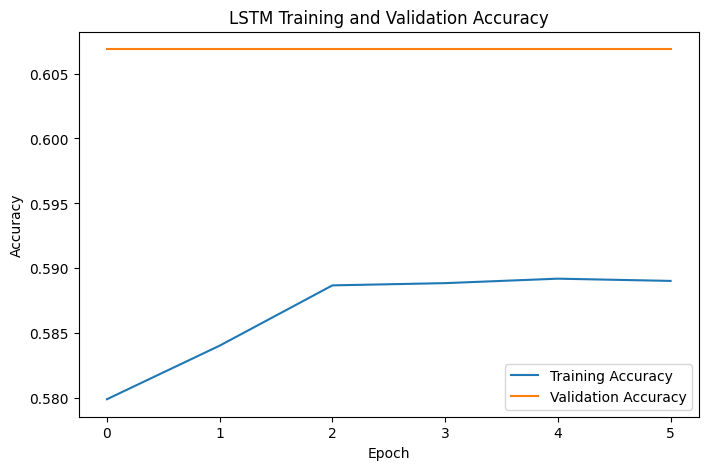

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "LSTM Training and Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

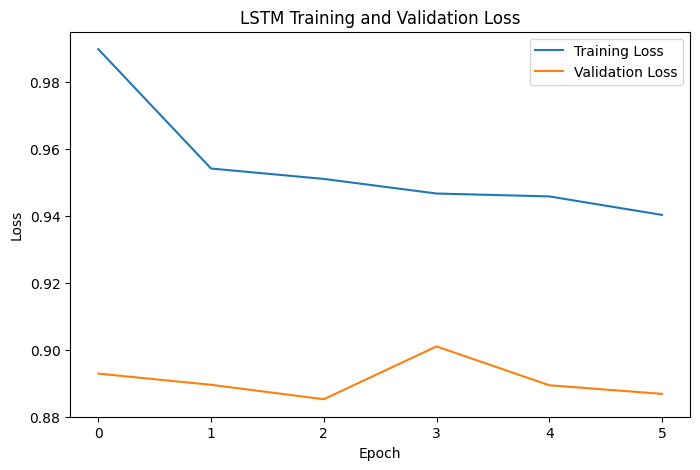

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "LSTM Training and Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [39]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print(
    "Test Loss:",
    round(
        test_loss,
        4
    )
)

print(
    "Test Accuracy:",
    round(
        test_accuracy * 100,
        2
    ),
    "%"
)

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5926 - loss: 0.9202
Test Loss: 0.9202
Test Accuracy: 59.26 %


In [40]:
prediction_probabilities = model.predict(
    X_test_pad
)

y_pred = np.argmax(
    prediction_probabilities,
    axis=1
)

print("Predictions generated successfully.")

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Predictions generated successfully.


In [41]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "LSTM Classification Accuracy:",
    round(
        accuracy * 100,
        2
    ),
    "%"
)

LSTM Classification Accuracy: 59.26 %


In [42]:
print(
    "CLASSIFICATION REPORT"
)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       114
     Neutral       0.59      1.00      0.74      1078
     No_idea       0.00      0.00      0.00        31
    Positive       0.00      0.00      0.00       596

    accuracy                           0.59      1819
   macro avg       0.15      0.25      0.19      1819
weighted avg       0.35      0.59      0.44      1819



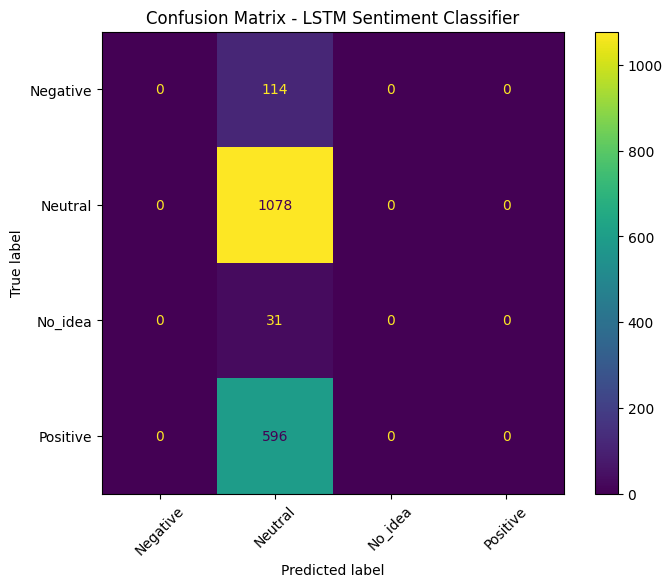

In [43]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title(
    "Confusion Matrix - LSTM Sentiment Classifier"
)

plt.show()

In [44]:
results = pd.DataFrame({
    "Tweet": X_test,
    "Actual_Label": y_test,
    "Predicted_Label": y_pred
})

results["Actual_Sentiment"] = label_encoder.inverse_transform(
    results["Actual_Label"]
)

results["Predicted_Sentiment"] = label_encoder.inverse_transform(
    results["Predicted_Label"]
)

display(
    results[
        [
            "Tweet",
            "Actual_Sentiment",
            "Predicted_Sentiment"
        ]
    ].head(20)
)

,Tweet,Actual_Sentiment,Predicted_Sentiment
0,temp appletore set up for sxsw yay link austin...,Positive,Neutral
1,googles envisions locationbased future link sx...,Neutral,Neutral
2,the league of extraordinary h ckers presented ...,Neutral,Neutral
3,thanks for hosting this event sxsw sxswi iwant...,Neutral,Neutral
4,alarms should go off if you allow users to gen...,Neutral,Neutral
5,google previews updated blogger interface at s...,Neutral,Neutral
6,new ipad apps for speechtherapy and communicat...,Neutral,Neutral
7,sxsw novelty of ipad news apps fades fast amon...,Negative,Neutral
8,takin galaxys g test drive sxsw n c how tmobil...,Neutral,Neutral
9,at sxsw apple schools the marketing experts sx...,Neutral,Neutral


In [45]:
correct_predictions = results[
    results["Actual_Sentiment"]
    ==
    results["Predicted_Sentiment"]
]

print(
    "Correct Predictions:",
    len(correct_predictions)
)

display(
    correct_predictions[
        [
            "Tweet",
            "Actual_Sentiment",
            "Predicted_Sentiment"
        ]
    ].head(10)
)

Correct Predictions: 1078


,Tweet,Actual_Sentiment,Predicted_Sentiment
1,googles envisions locationbased future link sx...,Neutral,Neutral
2,the league of extraordinary h ckers presented ...,Neutral,Neutral
3,thanks for hosting this event sxsw sxswi iwant...,Neutral,Neutral
4,alarms should go off if you allow users to gen...,Neutral,Neutral
5,google previews updated blogger interface at s...,Neutral,Neutral
6,new ipad apps for speechtherapy and communicat...,Neutral,Neutral
8,takin galaxys g test drive sxsw n c how tmobil...,Neutral,Neutral
9,at sxsw apple schools the marketing experts sx...,Neutral,Neutral
10,the line for the sxsw apple store is oddly not...,Neutral,Neutral
11,heading to sxsw austin tx staying with ûó lon...,Neutral,Neutral


In [46]:
wrong_predictions = results[
    results["Actual_Sentiment"]
    !=
    results["Predicted_Sentiment"]
]

print(
    "Incorrect Predictions:",
    len(wrong_predictions)
)

display(
    wrong_predictions[
        [
            "Tweet",
            "Actual_Sentiment",
            "Predicted_Sentiment"
        ]
    ].head(10)
)

Incorrect Predictions: 741


,Tweet,Actual_Sentiment,Predicted_Sentiment
0,temp appletore set up for sxsw yay link austin...,Positive,Neutral
7,sxsw novelty of ipad news apps fades fast amon...,Negative,Neutral
12,traded the xoom i won at the js party for the ...,Positive,Neutral
13,the hannukah miracle of the morning uncharged ...,Positive,Neutral
17,how can google load those maps so fast yet i c...,No_idea,Neutral
20,youll have to wait weeks for an ipad but not a...,Negative,Neutral
23,alert the media i just saw the one and only an...,Positive,Neutral
26,check the latest stream at apples store at sxs...,Positive,Neutral
28,sxsw is exposing my iphones horrendous battery...,Negative,Neutral
30,rt and it will suck rt rt google will preview ...,Negative,Neutral


In [47]:
def predict_sentiment(tweet):

    # Clean text
    cleaned = clean_tweet(
        tweet
    )

    # Tokenize
    sequence = tokenizer.texts_to_sequences(
        [cleaned]
    )

    # Padding
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    # Predict
    prediction = model.predict(
        padded,
        verbose=0
    )

    predicted_class = np.argmax(
        prediction,
        axis=1
    )[0]

    sentiment = label_encoder.inverse_transform(
        [predicted_class]
    )[0]

    confidence = np.max(
        prediction
    ) * 100

    print("Tweet:")
    print(tweet)

    print(
        "\nPredicted Sentiment:",
        sentiment
    )

    print(
        "Confidence:",
        round(
            confidence,
            2
        ),
        "%"
    )

In [48]:
predict_sentiment(
    "I absolutely love my new iPhone. Apple has done an amazing job!"
)

Tweet:
I absolutely love my new iPhone. Apple has done an amazing job!

Predicted Sentiment: Neutral
Confidence: 58.45 %


In [49]:
predict_sentiment(
    "My new iPhone keeps crashing and I am extremely disappointed with Apple."
)

Tweet:
My new iPhone keeps crashing and I am extremely disappointed with Apple.

Predicted Sentiment: Neutral
Confidence: 58.45 %


In [50]:
predict_sentiment(
    "Google announced a new Android update today."
)

Tweet:
Google announced a new Android update today.

Predicted Sentiment: Neutral
Confidence: 58.46 %


In [51]:
predict_sentiment(
    "The Google phone was released yesterday."
)

Tweet:
The Google phone was released yesterday.

Predicted Sentiment: Neutral
Confidence: 58.46 %


In [52]:
model.save(
    "/content/twitter_sentiment_lstm.keras"
)

print(
    "LSTM model saved successfully."
)

LSTM model saved successfully.


In [53]:
import pickle

with open(
    "/content/twitter_tokenizer.pkl",
    "wb"
) as file:

    pickle.dump(
        tokenizer,
        file
    )

print(
    "Tokenizer saved successfully."
)

Tokenizer saved successfully.


In [54]:
with open(
    "/content/sentiment_label_encoder.pkl",
    "wb"
) as file:

    pickle.dump(
        label_encoder,
        file
    )

print(
    "Label Encoder saved successfully."
)

Label Encoder saved successfully.


In [55]:
print("=" * 60)

print(
    "TWITTER SENTIMENT ANALYSIS USING LSTM"
)

print("=" * 60)

print(
    "Problem Type:",
    "Multi-Class Text Classification"
)

print(
    "Deep Learning Model:",
    "LSTM"
)

print(
    "Number of Classes:",
    NUM_CLASSES
)

print(
    "Sentiment Classes:",
    list(
        label_encoder.classes_
    )
)

print(
    "Vocabulary Size:",
    VOCAB_SIZE
)

print(
    "Maximum Sequence Length:",
    MAX_LENGTH
)

print(
    "Optimizer:",
    "Adam"
)

print(
    "Loss Function:",
    "Sparse Categorical Crossentropy"
)

print(
    "Output Activation:",
    "Softmax"
)

print(
    "Test Accuracy:",
    round(
        test_accuracy * 100,
        2
    ),
    "%"
)

print("=" * 60)

TWITTER SENTIMENT ANALYSIS USING LSTM
Problem Type: Multi-Class Text Classification
Deep Learning Model: LSTM
Number of Classes: 4
Sentiment Classes: ['Negative', 'Neutral', 'No_idea', 'Positive']
Vocabulary Size: 10000
Maximum Sequence Length: 50
Optimizer: Adam
Loss Function: Sparse Categorical Crossentropy
Output Activation: Softmax
Test Accuracy: 59.26 %


In [56]:
bilstm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LENGTH
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.5),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

In [57]:
bilstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [58]:
bilstm_history = bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.20,
    epochs=15,
    batch_size=32,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - accuracy: 0.5705 - loss: 0.9647 - val_accuracy: 0.6082 - val_loss: 0.8593
Epoch 2/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.6623 - loss: 0.8063 - val_accuracy: 0.6749 - val_loss: 0.7769
Epoch 3/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 23s 84ms/step - accuracy: 0.7772 - loss: 0.5958 - val_accuracy: 0.6694 - val_loss: 0.8013
Epoch 4/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - accuracy: 0.8422 - loss: 0.4496 - val_accuracy: 0.6522 - val_loss: 0.8967
Epoch 5/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 25s 104ms/step - accuracy: 0.8737 - loss: 0.3585 - val_accuracy: 0.6674 - val_loss: 1.0403


In [59]:
bilstm_loss, bilstm_accuracy = bilstm_model.evaluate(
    X_test_pad,
    y_test
)

print(
    "Bidirectional LSTM Test Accuracy:",
    round(
        bilstm_accuracy * 100,
        2
    ),
    "%"
)

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6471 - loss: 0.8094
Bidirectional LSTM Test Accuracy: 64.71 %


In [60]:
comparison = pd.DataFrame({

    "Model": [
        "LSTM",
        "Bidirectional LSTM"
    ],

    "Test Accuracy": [
        test_accuracy * 100,
        bilstm_accuracy * 100
    ]

})

display(comparison)

,Model,Test Accuracy
0,LSTM,59.263331
1,Bidirectional LSTM,64.705884


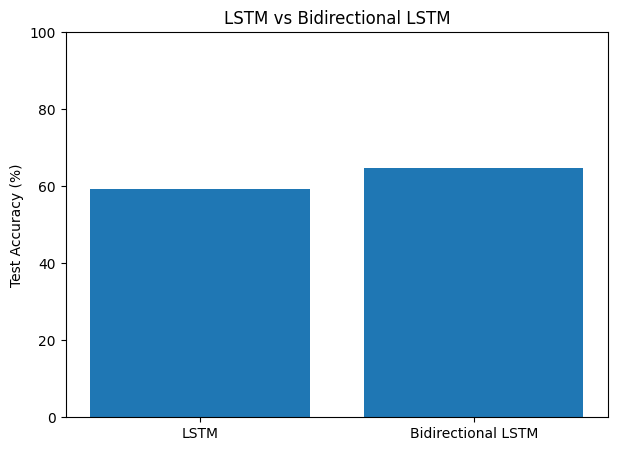

In [61]:
plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Model"],
    comparison["Test Accuracy"]
)

plt.ylabel(
    "Test Accuracy (%)"
)

plt.title(
    "LSTM vs Bidirectional LSTM"
)

plt.ylim(
    0,
    100
)

plt.show()